Implemeent Baatch gradient descent for softmax refression

In [305]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

In [12]:
X,y = make_classification(10000, 10, n_classes=3, n_informative=5, random_state=42)

In [13]:
X.shape, y.shape

((10000, 10), (10000,))

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [27]:
lr = LogisticRegression(multi_class='multinomial')
lr.fit(X_train, y_train)
f1_score(y_test, lr.predict(X_test),average='micro')

0.6772

---

In [30]:
X_train.shape

(7500, 10)

In [350]:
def batch_gradient_descent(X,y,learning_rate=0.1,epochs=10, early_stopping=None):
    if early_stopping:
        X, X_val, y, y_val = train_test_split(X, y, test_size=0.25, random_state=42)
        cost_val = 1e10
        no_improvement_rounds = 0
        history_val = []
    m = X.shape[0]
    history = []
    theta = np.random.randn(3,10)
    for _ in tqdm(range(epochs)):
        score = (X @ theta.T)
        prob = (np.exp(score)/np.exp(score).sum(axis=1).reshape(-1,1))
        cost = (-1/m)*(np.sum(np.log(prob)[np.arange(prob.shape[0]), y]))
        history.append(cost)
        gradient_0 = (1/m)*((prob[:,0] - np.asarray(y==0,'int')) @ X)
        gradient_1 = (1/m)*((prob[:,1] - np.asarray(y==1,'int')) @ X)
        gradient_2 = (1/m)*((prob[:,2] - np.asarray(y==2,'int')) @ X)
        gradient = np.vstack((gradient_0, gradient_1, gradient_2))
        theta = theta - learning_rate*gradient
        if early_stopping:
            score_val = (X_val @ theta.T)
            prob_val = (np.exp(score_val)/np.exp(score_val).sum(axis=1).reshape(-1,1))
            cost_val_tmp = (-1/m)*(np.sum(np.log(prob_val)[np.arange(prob_val.shape[0]), y_val]))
            history_val.append(cost_val_tmp)
            if cost_val_tmp >= cost_val:
                no_improvement_rounds+=1
                if no_improvement_rounds == early_stopping:
                    print('Early Stopping!')
                    break
            else:
                cost_val = cost_val_tmp
                no_improvement_rounds=0
    plt.plot(range(len(history)), history,'rx',ls='--')
    if early_stopping:
        plt.plot(range(len(history_val)), history_val,'bx',ls='--')
    plt.xlabel('Epoch #')
    plt.ylabel('Cost')
    
    return history, theta


 40%|███▉      | 395/1000 [00:01<00:01, 334.43it/s]


Early Stopping!


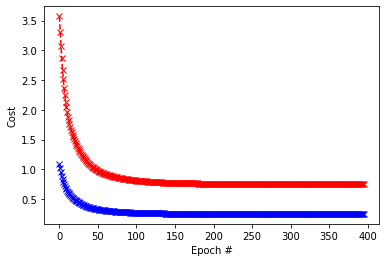

In [355]:
history, theta = batch_gradient_descent(X_train, y_train, epochs=1000, early_stopping=10)

In [356]:
f1_score(y_test, (X_test @ theta.T).argmax(axis=1), average='micro')

0.6612